# ToDo

# Подготовка

## Настройка графики

In [1]:
#windows.options(height=5.4, width=7)
oldpar = par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE);

require(vcd, quietly = TRUE, warn.conflicts = FALSE);
require(coin, quietly = TRUE, warn.conflicts = FALSE);          # independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE);     # HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE);      # kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE);       # for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE);     # numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE);
require(lattice, quietly = TRUE, warn.conflicts = FALSE);
require(mosaic, quietly = TRUE, warn.conflicts = FALSE);
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE);
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE);        # ggqqplot
#require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE);                            # flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE);    # ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE);        # ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE);       # ggparcoord


require(rstatix, quietly = TRUE);                               # identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE);
#require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE);
require(repr, quietly = TRUE, warn.conflicts = FALSE);

require(knitr, quietly = TRUE, warn.conflicts = FALSE);        # Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
#sessionInfo()
#options(encoding = "UTF-8")
lor = read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet="данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor = lor %>% 
    dplyr::select("id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                  ) %>%
    filter(локация != "полип") %>%
    filter(группа != "КГ1")
lor = as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа = factor(lor$группа, c("ОГ", "КГ"))
lor$"локация" = factor(lor$"локация")
lor$"этап" = factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
    group_by(id, группа, локация, этап) %>%
    summarise(
        across(c(
                "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                ),
            ~ median(.x, na.rm = TRUE)
        ),
        .groups = "drop"
        # mean_value = mean(measurement_value, na.rm = TRUE),
        # median_value = median(measurement_value, na.rm = TRUE),
        # sd_value = sd(measurement_value, na.rm = TRUE),
        # min_value = min(measurement_value, na.rm = TRUE),
        # max_value = max(measurement_value, na.rm = TRUE)
    ) %>%
    arrange(id) 
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable = 'группа'

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname = "круглоклеточная воспалительная инфильтрация"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

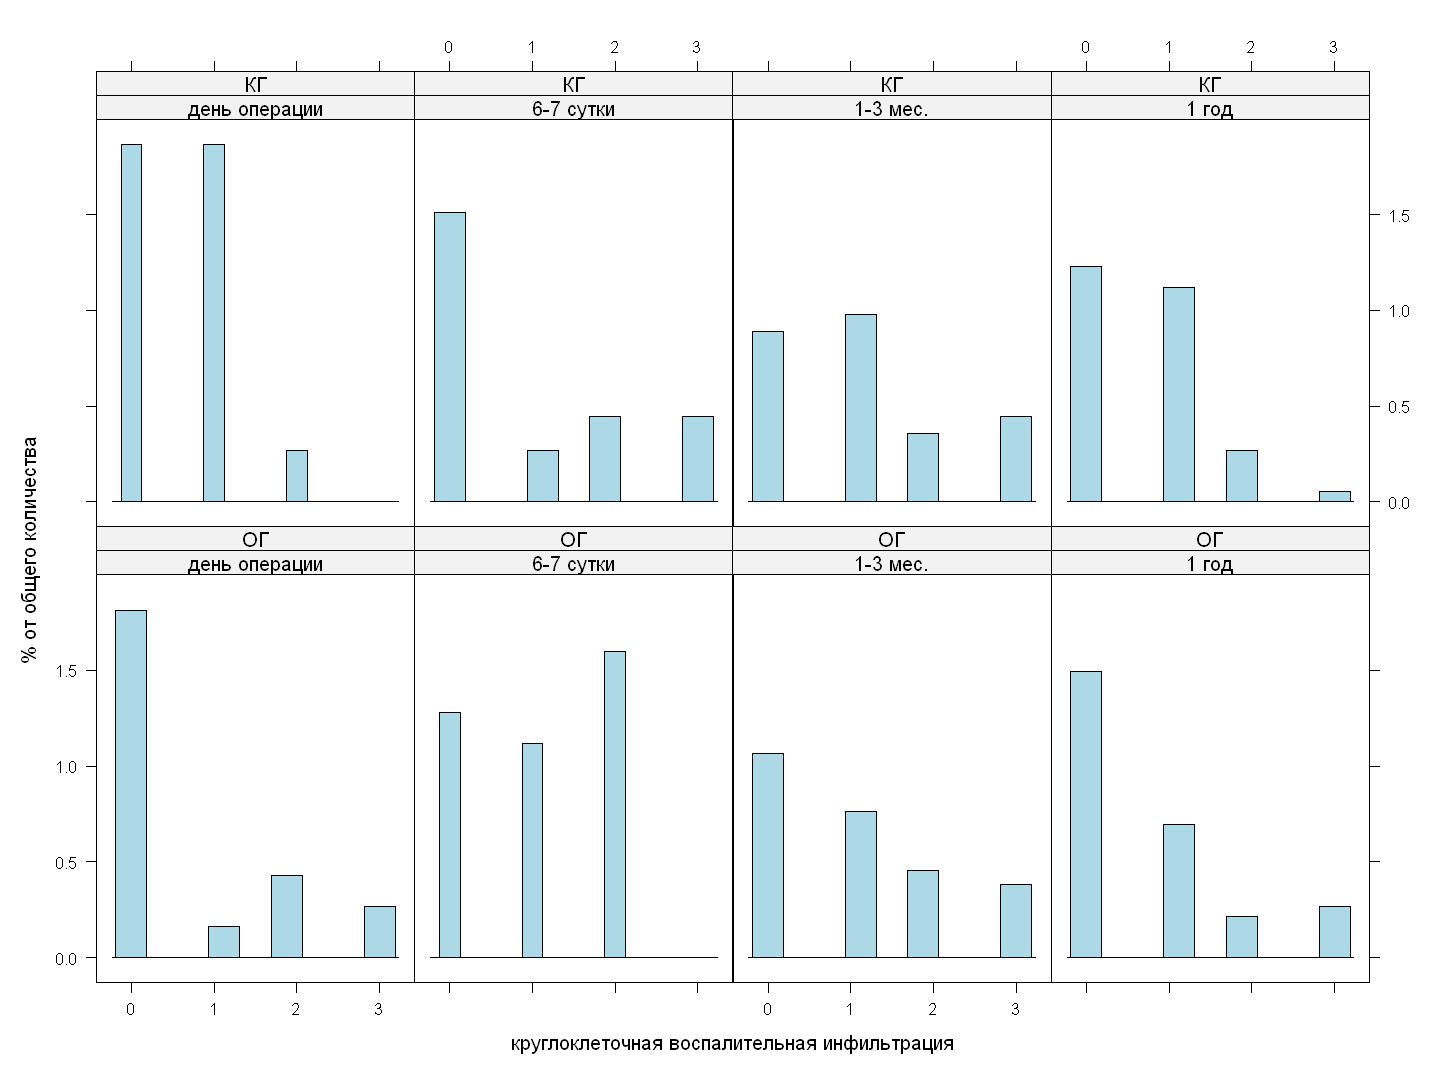

In [10]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      1.1333333 1.0742546 2.00  0   0   1 2.00    3     30
КГ: 1 год         0.6800000 0.7406561 1.00  0   0   1 1.00    3     50
КГ: 6-7 сутки     0.9333333 1.2015316 2.00  0   0   0 2.00    3     30
КГ: день операции 0.6000000 0.6324555 1.00  0   0   1 1.00    2     15
ОГ: 1-3 мес.      1.0571429 1.0831017 2.00  0   0   1 2.00    3     35
ОГ: 1 год         0.7200000 0.9905678 1.00  0   0   0 1.00    3     50
ОГ: 6-7 сутки     1.0800000 0.8621678 2.00  0   0   1 2.00    2     25
ОГ: день операции 0.6800000 1.0774119 1.75  0   0   0 1.75    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,1.75,3,0.6800000,1.0774119,50,0
КГ.день операции,0,0,1,1.00,2,0.6000000,0.6324555,15,0
ОГ.6-7 сутки,0,0,1,2.00,2,1.0800000,0.8621678,25,0
КГ.6-7 сутки,0,0,0,2.00,3,0.9333333,1.2015316,30,0
ОГ.1-3 мес.,0,0,1,2.00,3,1.0571429,1.0831017,35,0
КГ.1-3 мес.,0,0,1,2.00,3,1.1333333,1.0742546,30,0
ОГ.1 год,0,0,0,1.00,3,0.7200000,0.9905678,50,0
КГ.1 год,0,0,1,1.00,3,0.6800000,0.7406561,50,0


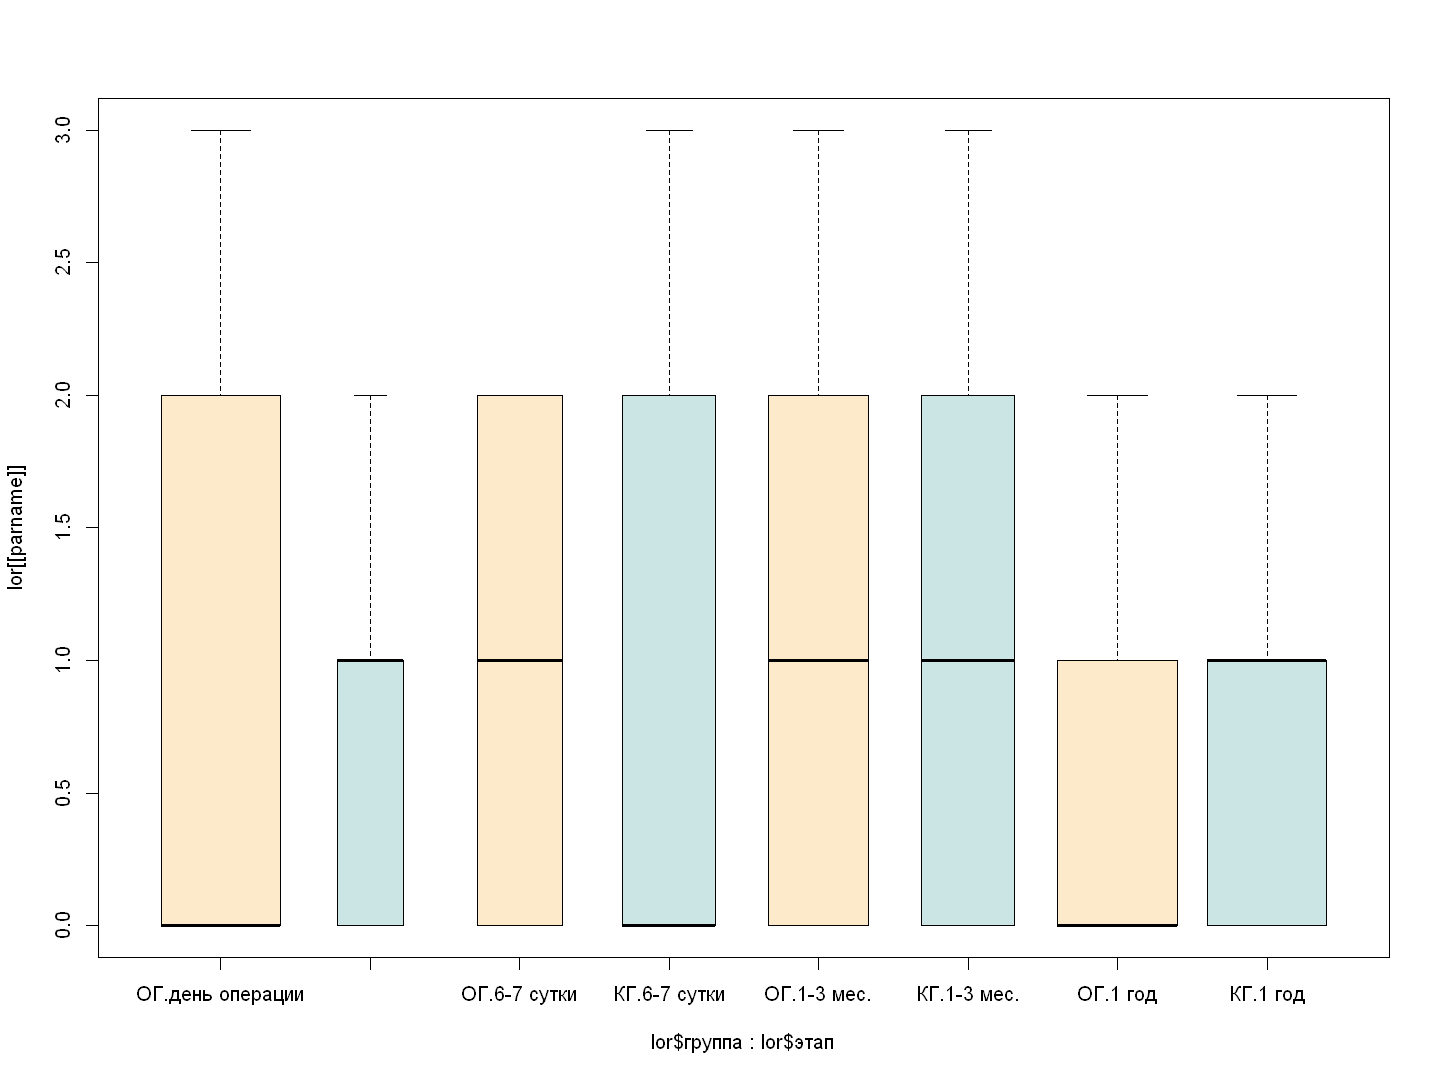

In [12]:
parname = sub("\\..*", "", parname)
# # beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
# #          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [13]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 341.5, p-value = 0.551
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.60534, p-value = 0.545
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 422.5, p-value = 0.3969
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.85622, p-value = 0.3919
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 500.5, p-value = 0.7404
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.33817, p-value 

## бокаловидные клетки

### Общее

In [14]:
parname = "бокаловидные клетки"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [15]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [16]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      0.5666667 0.8172002   1  0   0   0   1    3     30
КГ: 1 год         0.6800000 0.9987748   1  0   0   0   1    3     50
КГ: 6-7 сутки     0.0000000 0.0000000   0  0   0   0   0    0     30
КГ: день операции 0.0000000 0.0000000   0  0   0   0   0    0     15
ОГ: 1-3 мес.      0.7714286 1.0025178   1  0   0   0   1    3     35
ОГ: 1 год         0.4400000 0.9722685   0  0   0   0   0    3     50
ОГ: 6-7 сутки     0.0000000 0.0000000   0  0   0   0   0    0     25
ОГ: день операции 0.0800000 0.3404679   0  0   0   0   0    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0,2,0.0800000,0.3404679,50,0
КГ.день операции,0,0,0,0,0,0.0000000,0.0000000,15,0
ОГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,25,0
КГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,30,0
ОГ.1-3 мес.,0,0,0,1,3,0.7714286,1.0025178,35,0
КГ.1-3 мес.,0,0,0,1,3,0.5666667,0.8172002,30,0
ОГ.1 год,0,0,0,0,3,0.4400000,0.9722685,50,0
КГ.1 год,0,0,0,1,3,0.6800000,0.9987748,50,0


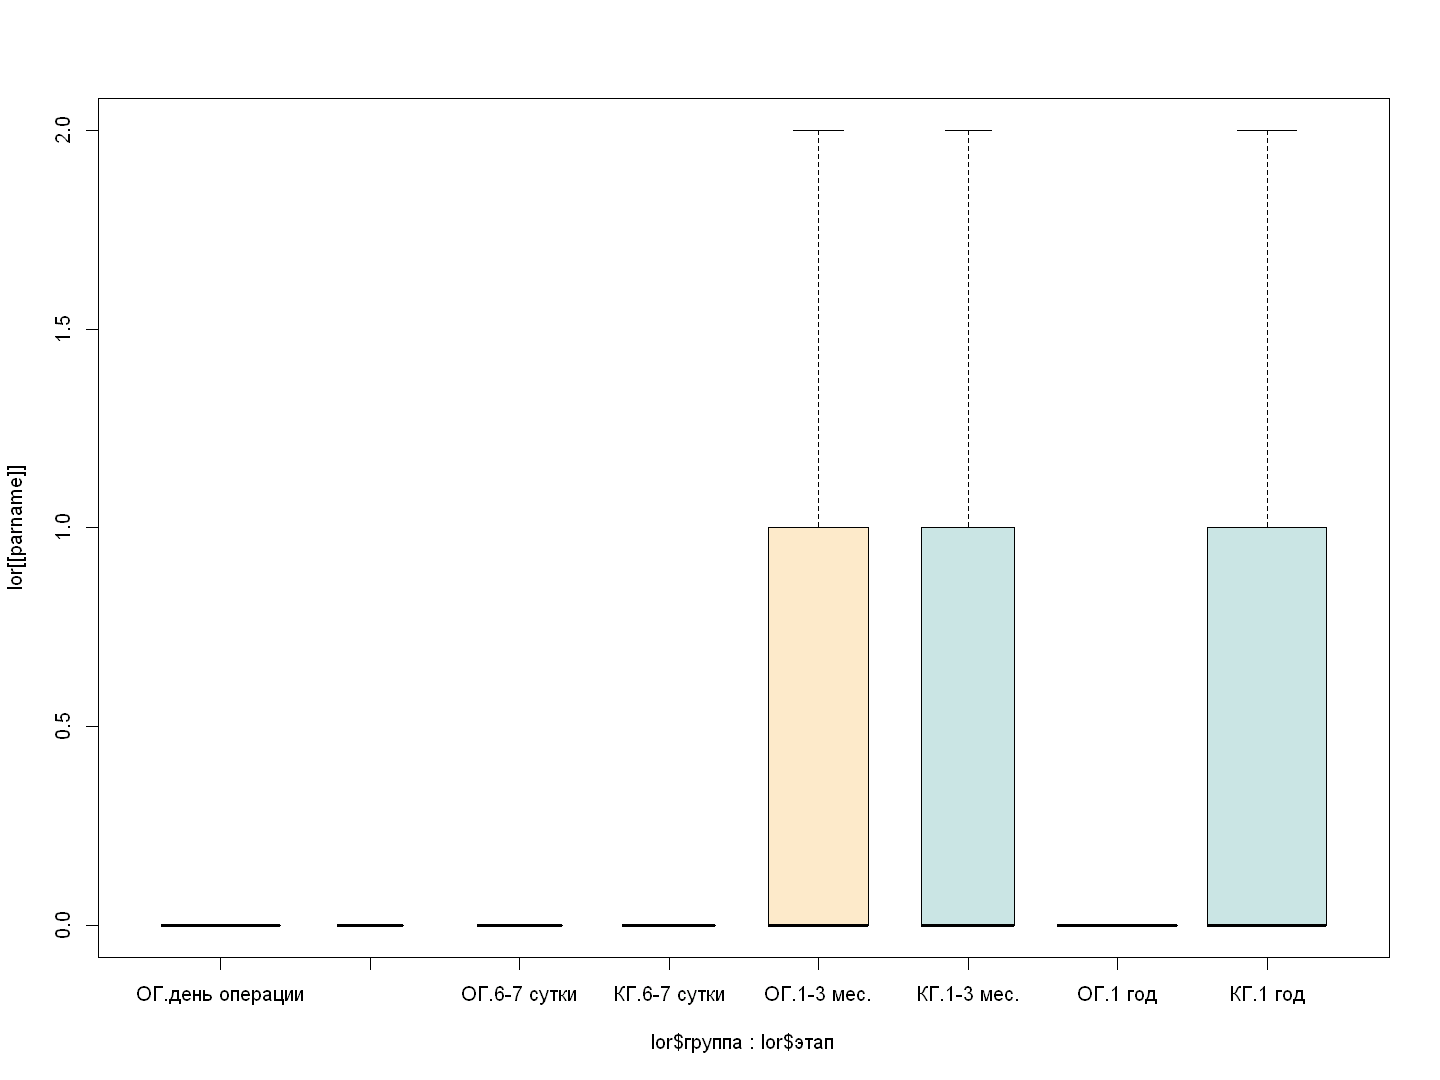

In [17]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [18]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 397.5, p-value = 0.3461
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.96362, p-value = 0.3352
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 375, p-value = NA
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = NaN, p-value = NA
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 573, p-value = 0.4843
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.70675, p-value = 0.4797
alterna

## отек

### Общее

In [19]:
parname = "отек"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

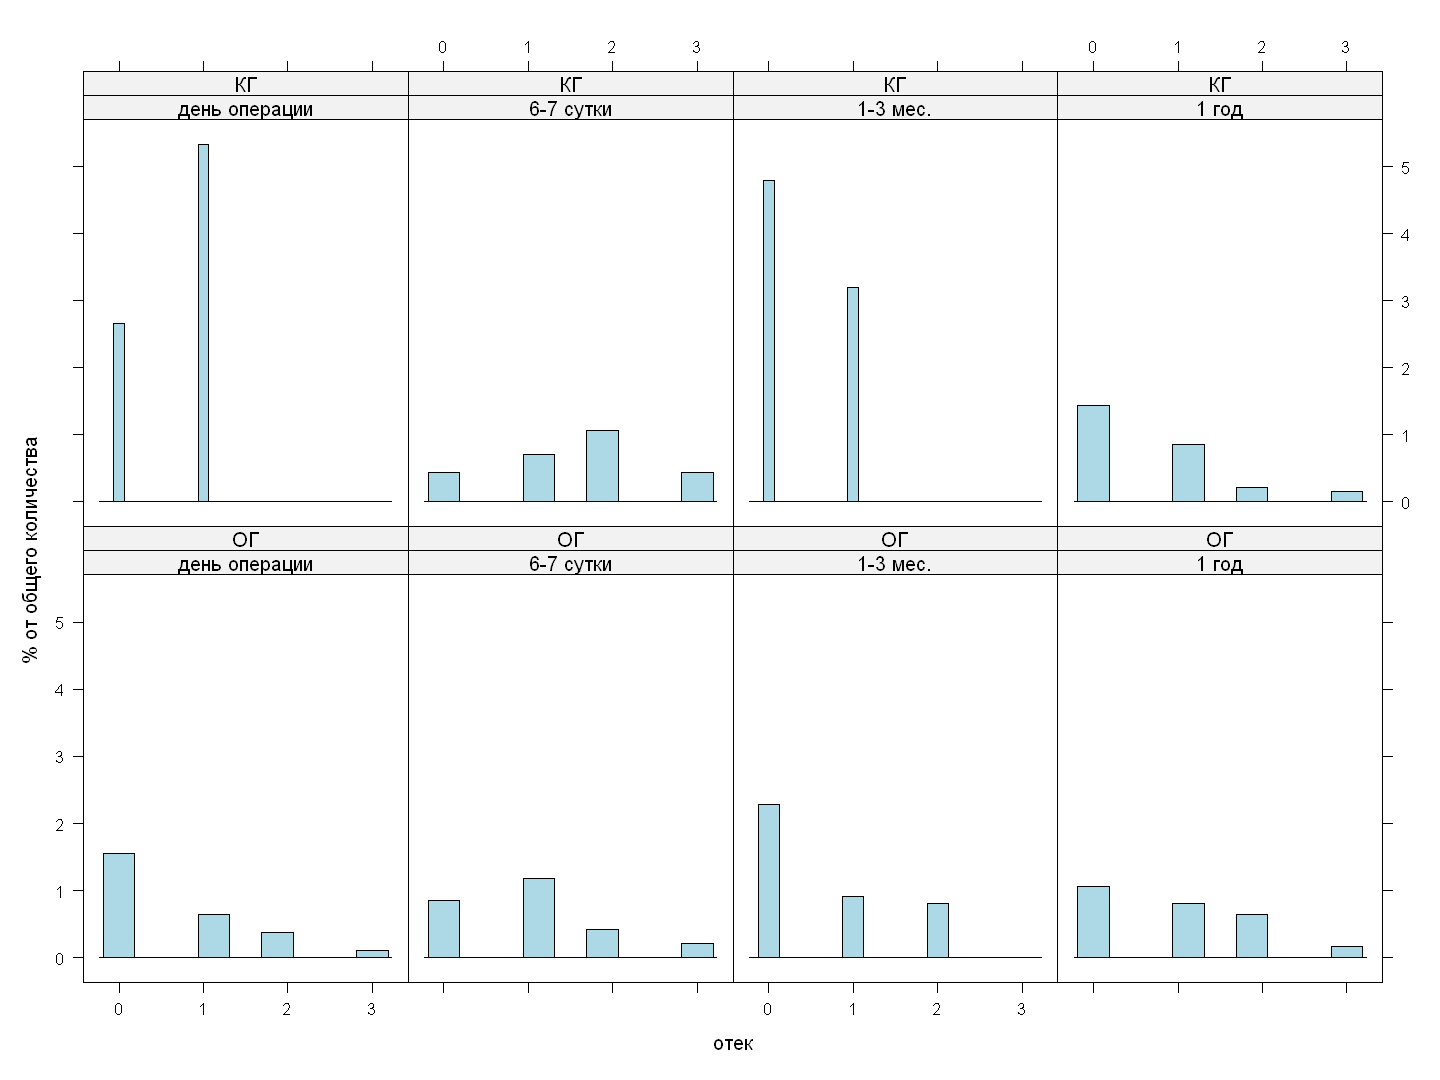

In [20]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [21]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      0.4000000 0.4982729   1  0   0   0   1    1     30
КГ: 1 год         0.6600000 0.8715457   1  0   0   0   1    3     50
КГ: 6-7 сутки     1.5666667 0.9714310   1  0   1   2   2    3     30
КГ: день операции 0.6666667 0.4879500   1  0   0   1   1    1     15
ОГ: 1-3 мес.      0.6285714 0.8075276   1  0   0   0   1    2     35
ОГ: 1 год         0.9600000 0.9467452   2  0   0   1   2    3     50
ОГ: 6-7 сутки     1.0000000 0.9128709   1  0   0   1   1    3     25
ОГ: день операции 0.6400000 0.8750510   1  0   0   0   1    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,1,3,0.6400000,0.8750510,50,0
КГ.день операции,0,0,1,1,1,0.6666667,0.4879500,15,0
ОГ.6-7 сутки,0,0,1,1,3,1.0000000,0.9128709,25,0
КГ.6-7 сутки,0,1,2,2,3,1.5666667,0.9714310,30,0
ОГ.1-3 мес.,0,0,0,1,2,0.6285714,0.8075276,35,0
КГ.1-3 мес.,0,0,0,1,1,0.4000000,0.4982729,30,0
ОГ.1 год,0,0,1,2,3,0.9600000,0.9467452,50,0
КГ.1 год,0,0,0,1,3,0.6600000,0.8715457,50,0


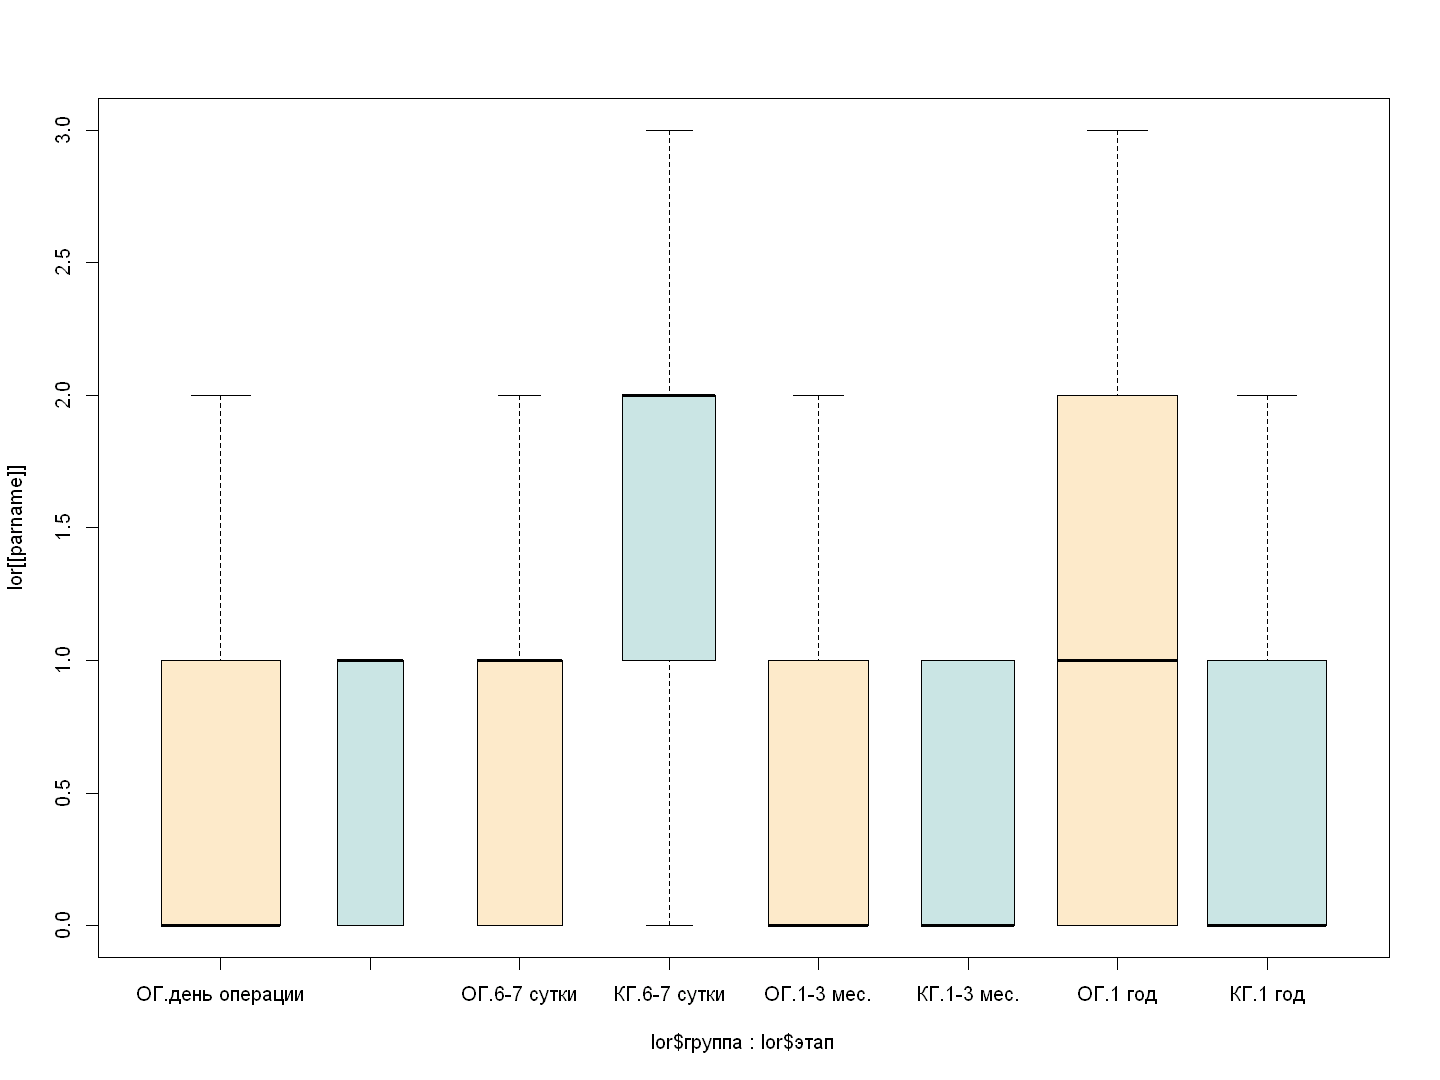

In [22]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [23]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 327.5, p-value = 0.4182
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.81821, p-value = 0.4132
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 250, p-value = 0.02816
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -2.2038, p-value = 0.02754
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 582, p-value = 0.3968
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.85478, p-value =

## реснички эпителия

### Общее

In [24]:
parname = "реснички эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

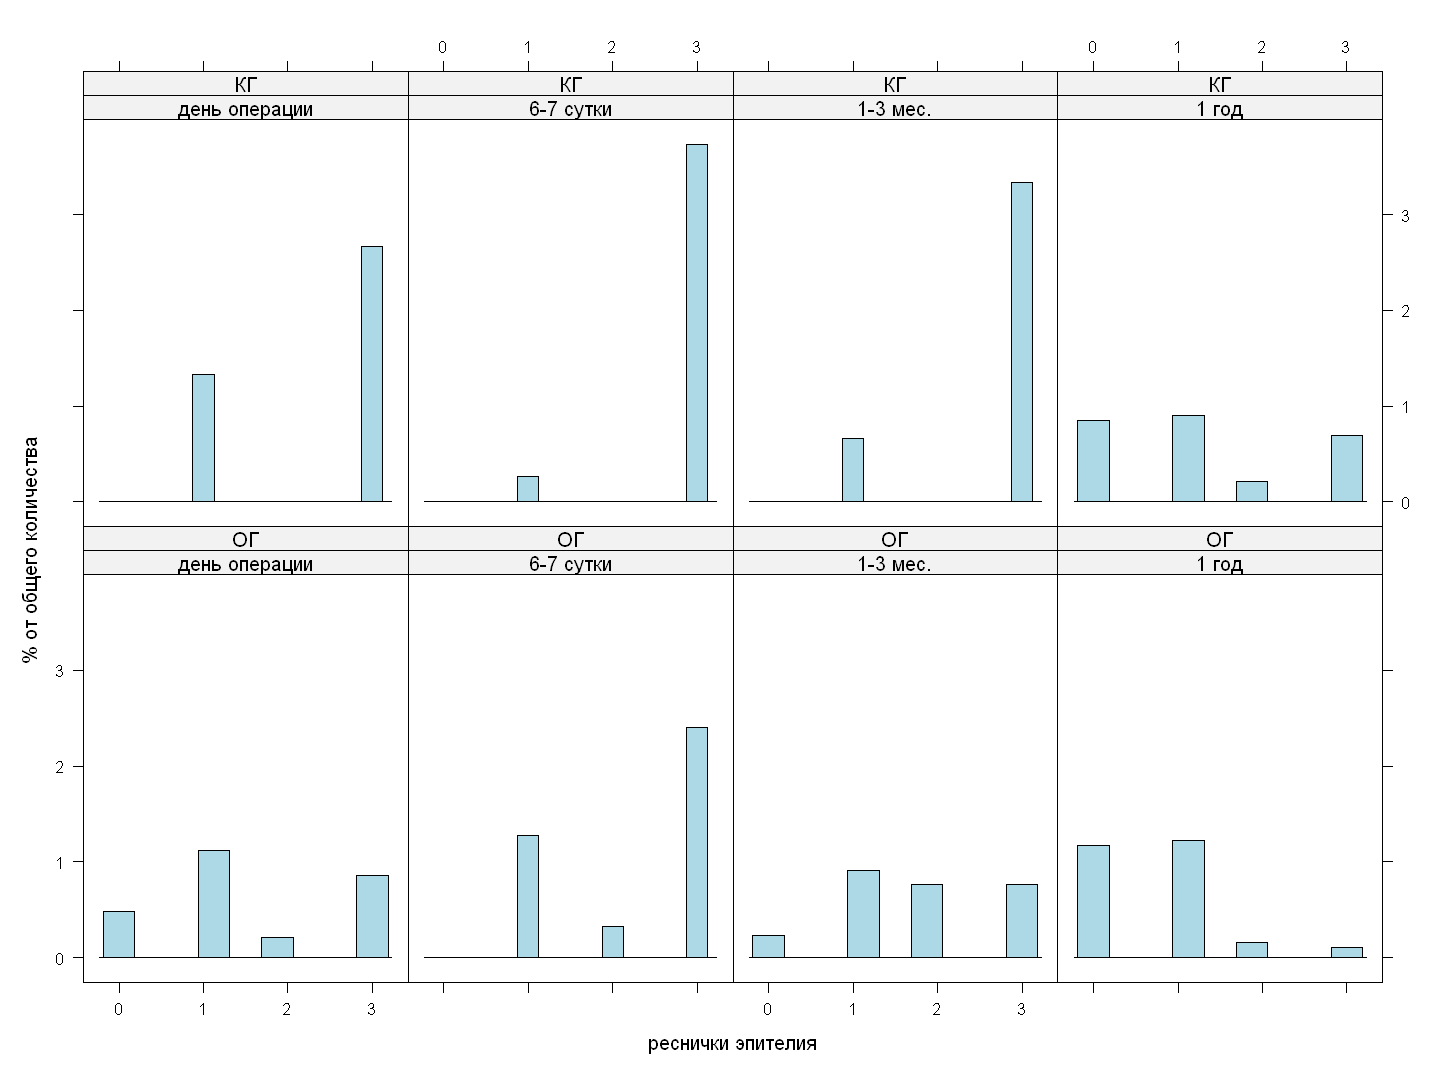

In [25]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [26]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                      mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      2.666667 0.7580980 0.00  1   3   3 3.00    3     30
КГ: 1 год         1.280000 1.1787229 2.75  0   0   1 2.75    3     50
КГ: 6-7 сутки     2.866667 0.5074163 0.00  1   3   3 3.00    3     30
КГ: день операции 2.333333 0.9759001 2.00  1   1   3 3.00    3     15
ОГ: 1-3 мес.      1.771429 0.9727376 2.00  0   1   2 3.00    3     35
ОГ: 1 год         0.700000 0.7626484 1.00  0   0   1 1.00    3     50
ОГ: 6-7 сутки     2.280000 0.9363048 2.00  1   1   3 3.00    3     25
ОГ: день операции 1.540000 1.1286618 2.00  0   1   1 3.00    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1,1,3.00,3,1.540000,1.1286618,50,0
КГ.день операции,1,1,3,3.00,3,2.333333,0.9759001,15,0
ОГ.6-7 сутки,1,1,3,3.00,3,2.280000,0.9363048,25,0
КГ.6-7 сутки,1,3,3,3.00,3,2.866667,0.5074163,30,0
ОГ.1-3 мес.,0,1,2,3.00,3,1.771429,0.9727376,35,0
КГ.1-3 мес.,1,3,3,3.00,3,2.666667,0.7580980,30,0
ОГ.1 год,0,0,1,1.00,3,0.700000,0.7626484,50,0
КГ.1 год,0,0,1,2.75,3,1.280000,1.1787229,50,0


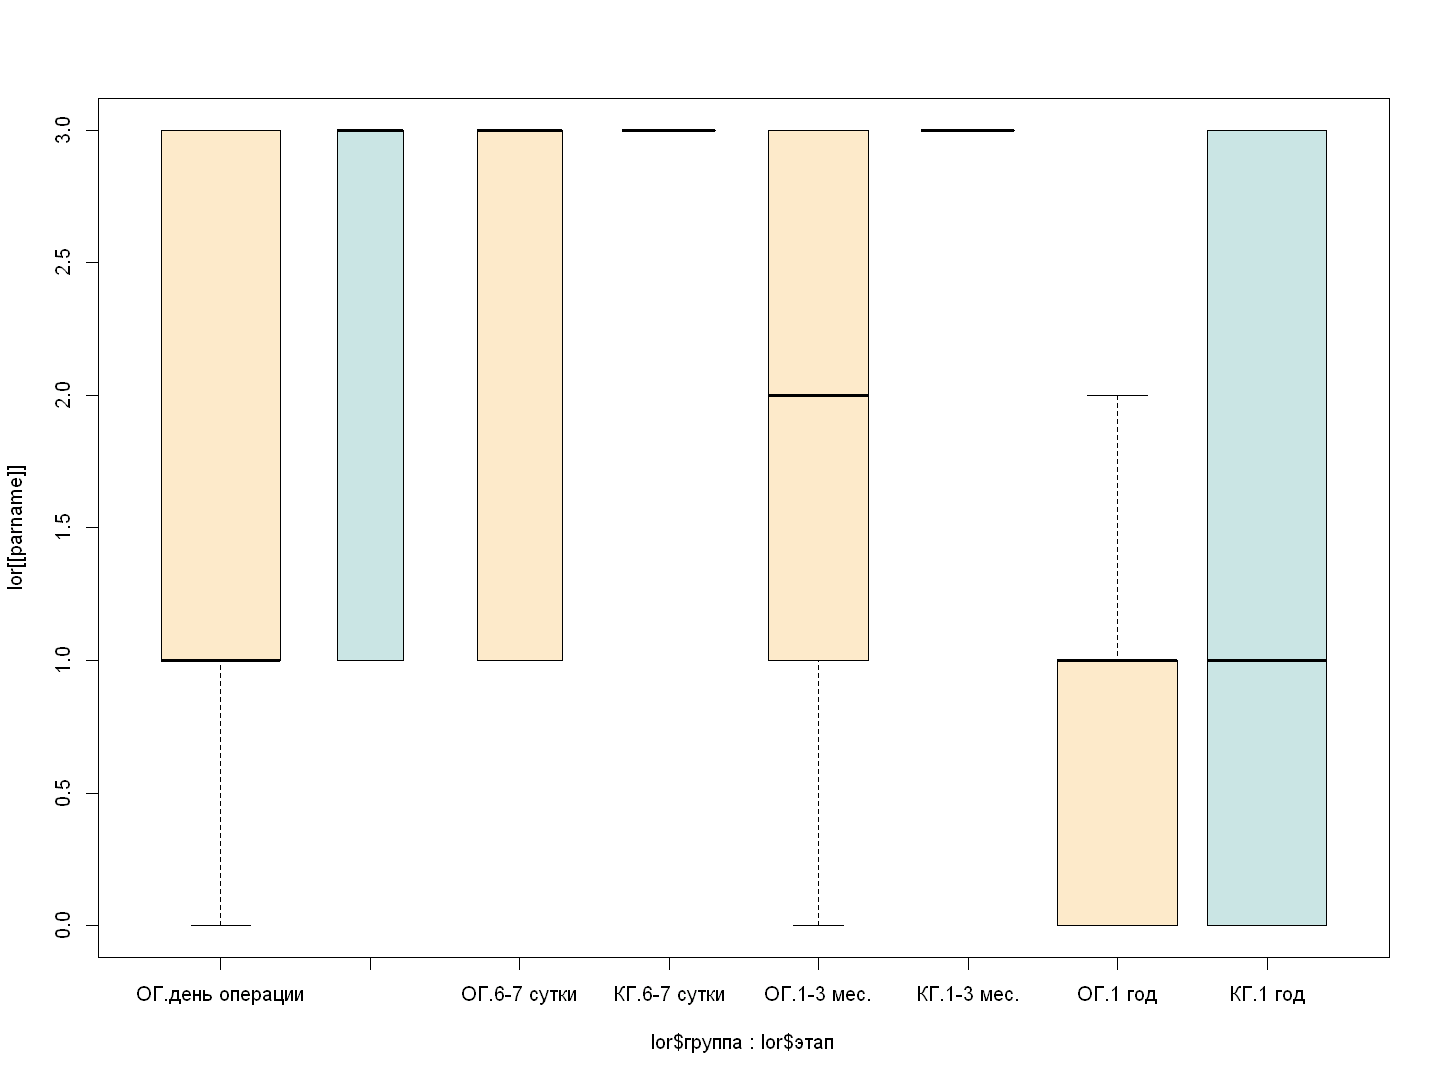

In [27]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [28]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 232.5, p-value = 0.01773
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -2.3797, p-value = 0.01733
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 252, p-value = 0.003953
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -2.8937, p-value = 0.003808
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 255, p-value = 9.211e-05
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.9177, p-v

## фиброз

### Общее

In [29]:
parname = "фиброз"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

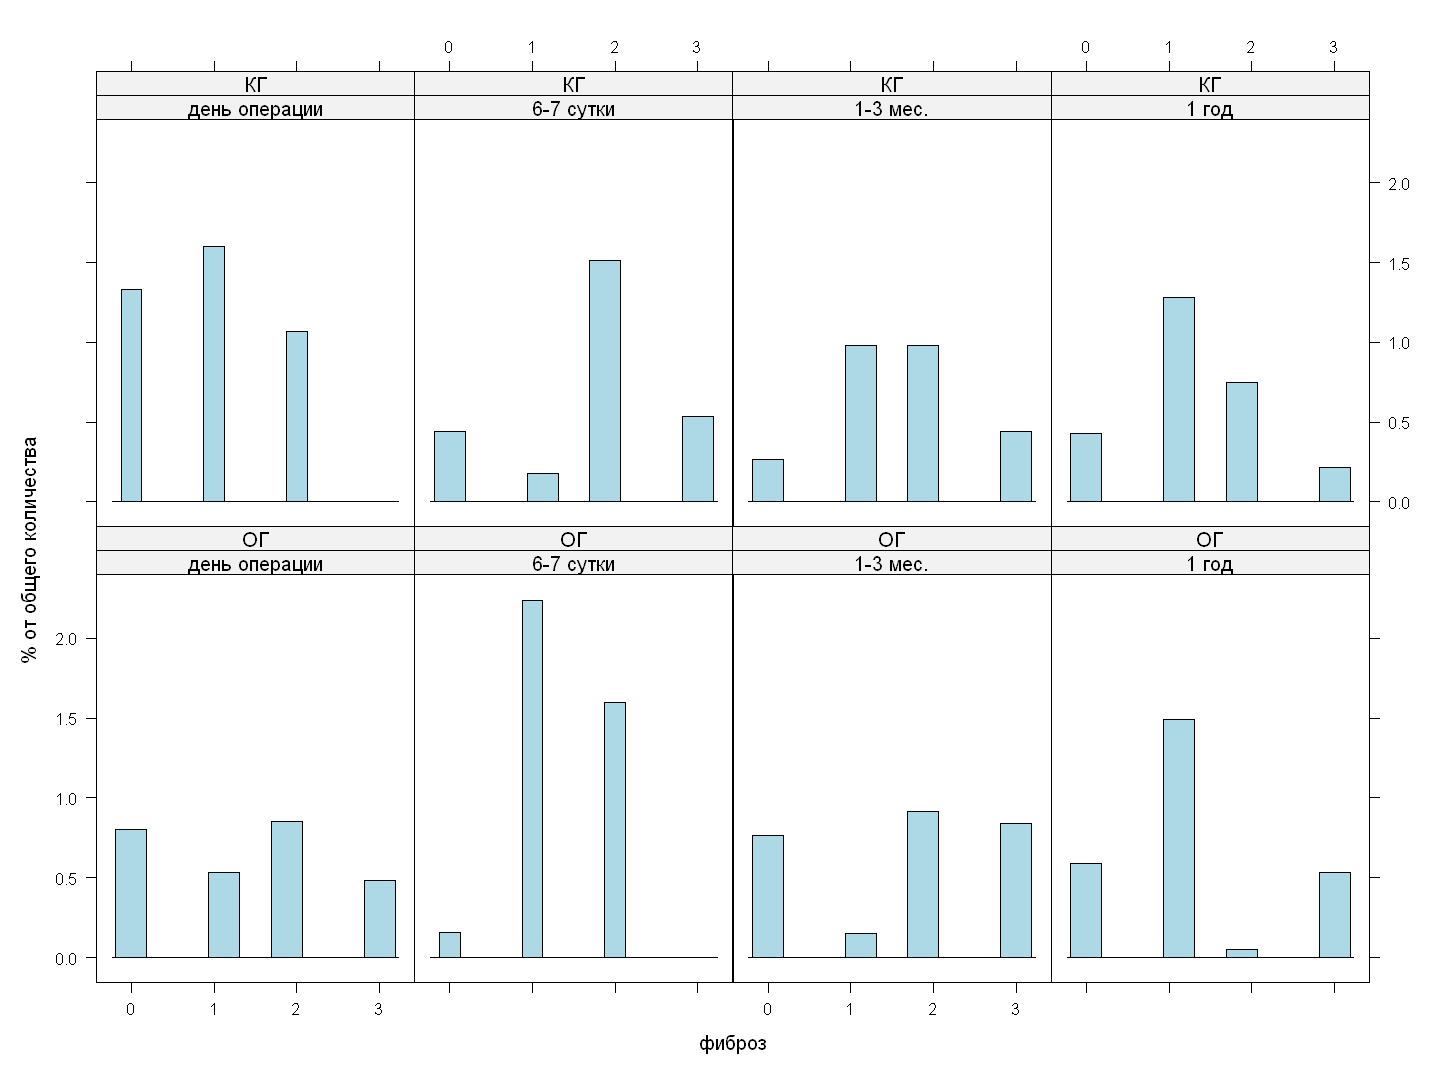

In [30]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [31]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      1.6000000 0.8944272 1.0  0   1 2.0 2.0    3     30
КГ: 1 год         1.2800000 0.8339725 1.0  0   1 1.0 2.0    3     50
КГ: 6-7 сутки     1.8000000 0.9613209 0.0  0   2 2.0 2.0    3     30
КГ: день операции 0.9333333 0.7988086 1.5  0   0 1.0 1.5    2     15
ОГ: 1-3 мес.      1.6857143 1.2071217 3.0  0   0 2.0 3.0    3     35
ОГ: 1 год         1.2000000 1.0101525 0.0  0   1 1.0 1.0    3     50
ОГ: 6-7 сутки     1.3600000 0.5686241 1.0  0   1 1.0 2.0    2     25
ОГ: день операции 1.3800000 1.1045361 2.0  0   0 1.5 2.0    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,1.5,2.0,3,1.3800000,1.1045361,50,0
КГ.день операции,0,0,1.0,1.5,2,0.9333333,0.7988086,15,0
ОГ.6-7 сутки,0,1,1.0,2.0,2,1.3600000,0.5686241,25,0
КГ.6-7 сутки,0,2,2.0,2.0,3,1.8000000,0.9613209,30,0
ОГ.1-3 мес.,0,0,2.0,3.0,3,1.6857143,1.2071217,35,0
КГ.1-3 мес.,0,1,2.0,2.0,3,1.6000000,0.8944272,30,0
ОГ.1 год,0,1,1.0,1.0,3,1.2000000,1.0101525,50,0
КГ.1 год,0,1,1.0,2.0,3,1.2800000,0.8339725,50,0


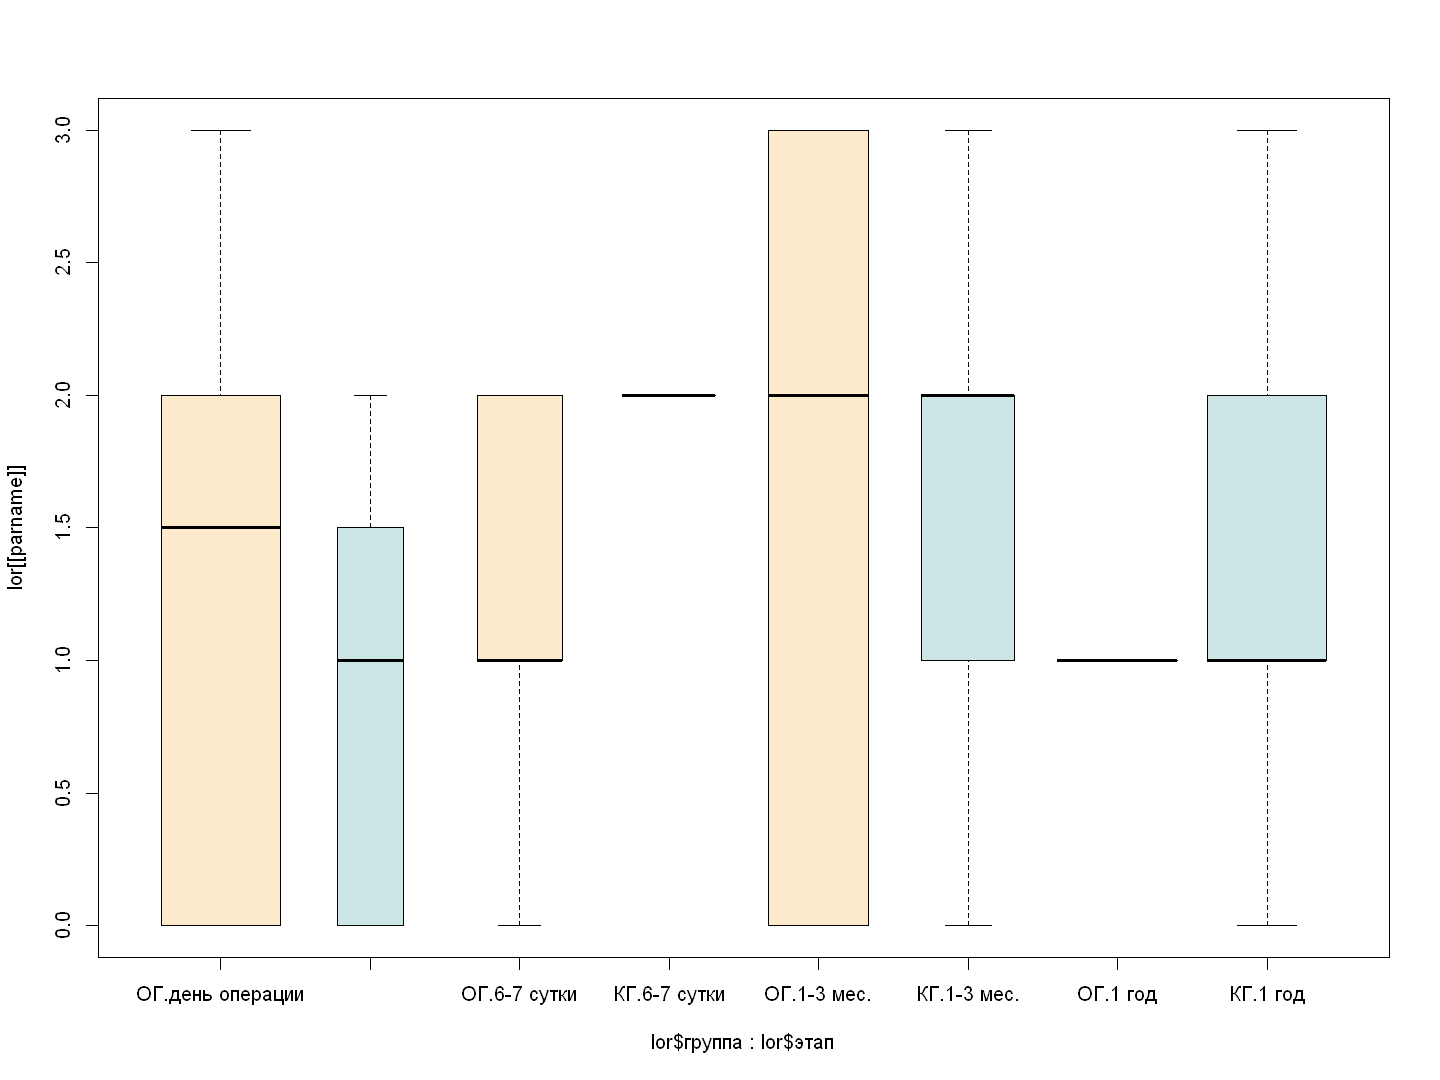

In [32]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [33]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 460.5, p-value = 0.1687
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.3846, p-value = 0.1662
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 241.5, p-value = 0.01503
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -2.4408, p-value = 0.01466
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 568.5, p-value = 0.5563
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.59517, p-value

## гиперплазия респираторного эпителия

### Общее

In [34]:
parname = "гиперплазия респираторного эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

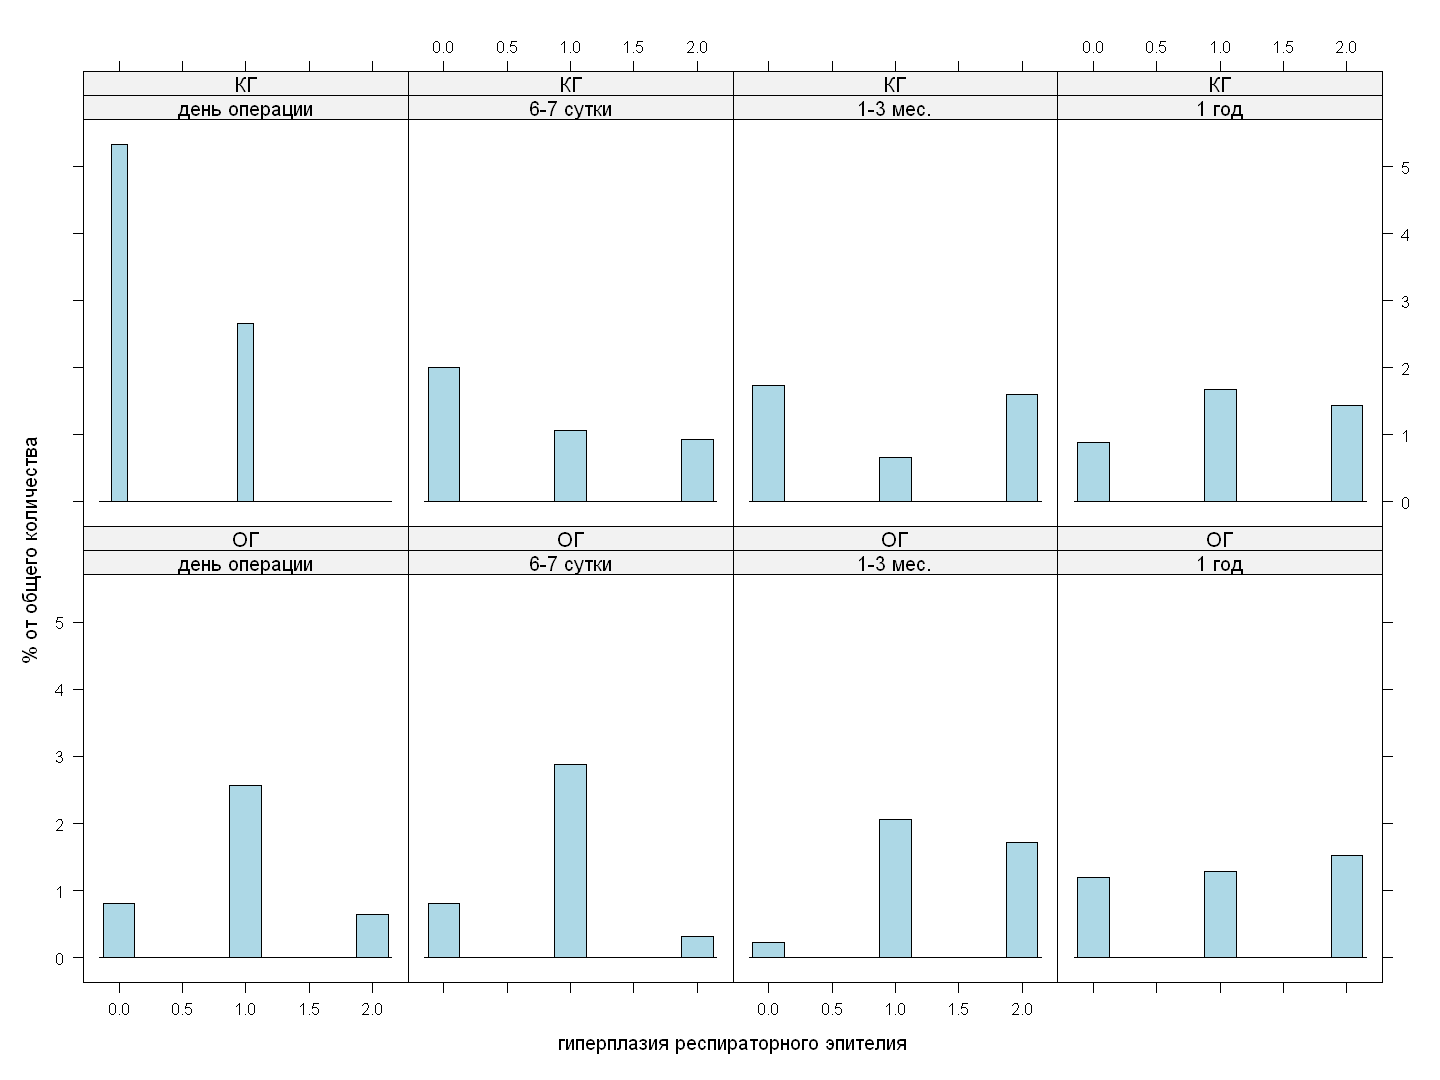

In [35]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [36]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      0.9666667 0.9278575   2  0   0 1.0   2    2     30
КГ: 1 год         1.1400000 0.7561989   1  0   1 1.0   2    2     50
КГ: 6-7 сутки     0.7333333 0.8276820   1  0   0 0.5   1    2     30
КГ: день операции 0.3333333 0.4879500   1  0   0 0.0   1    1     15
ОГ: 1-3 мес.      1.3714286 0.5983170   1  0   1 1.0   2    2     35
ОГ: 1 год         1.0800000 0.8290639   2  0   0 1.0   2    2     50
ОГ: 6-7 сутки     0.8800000 0.5259911   0  0   1 1.0   1    2     25
ОГ: день операции 0.9600000 0.6047432   0  0   1 1.0   1    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1,1.0,1,2,0.9600000,0.6047432,50,0
КГ.день операции,0,0,0.0,1,1,0.3333333,0.4879500,15,0
ОГ.6-7 сутки,0,1,1.0,1,2,0.8800000,0.5259911,25,0
КГ.6-7 сутки,0,0,0.5,1,2,0.7333333,0.8276820,30,0
ОГ.1-3 мес.,0,1,1.0,2,2,1.3714286,0.5983170,35,0
КГ.1-3 мес.,0,0,1.0,2,2,0.9666667,0.9278575,30,0
ОГ.1 год,0,0,1.0,2,2,1.0800000,0.8290639,50,0
КГ.1 год,0,1,1.0,2,2,1.1400000,0.7561989,50,0


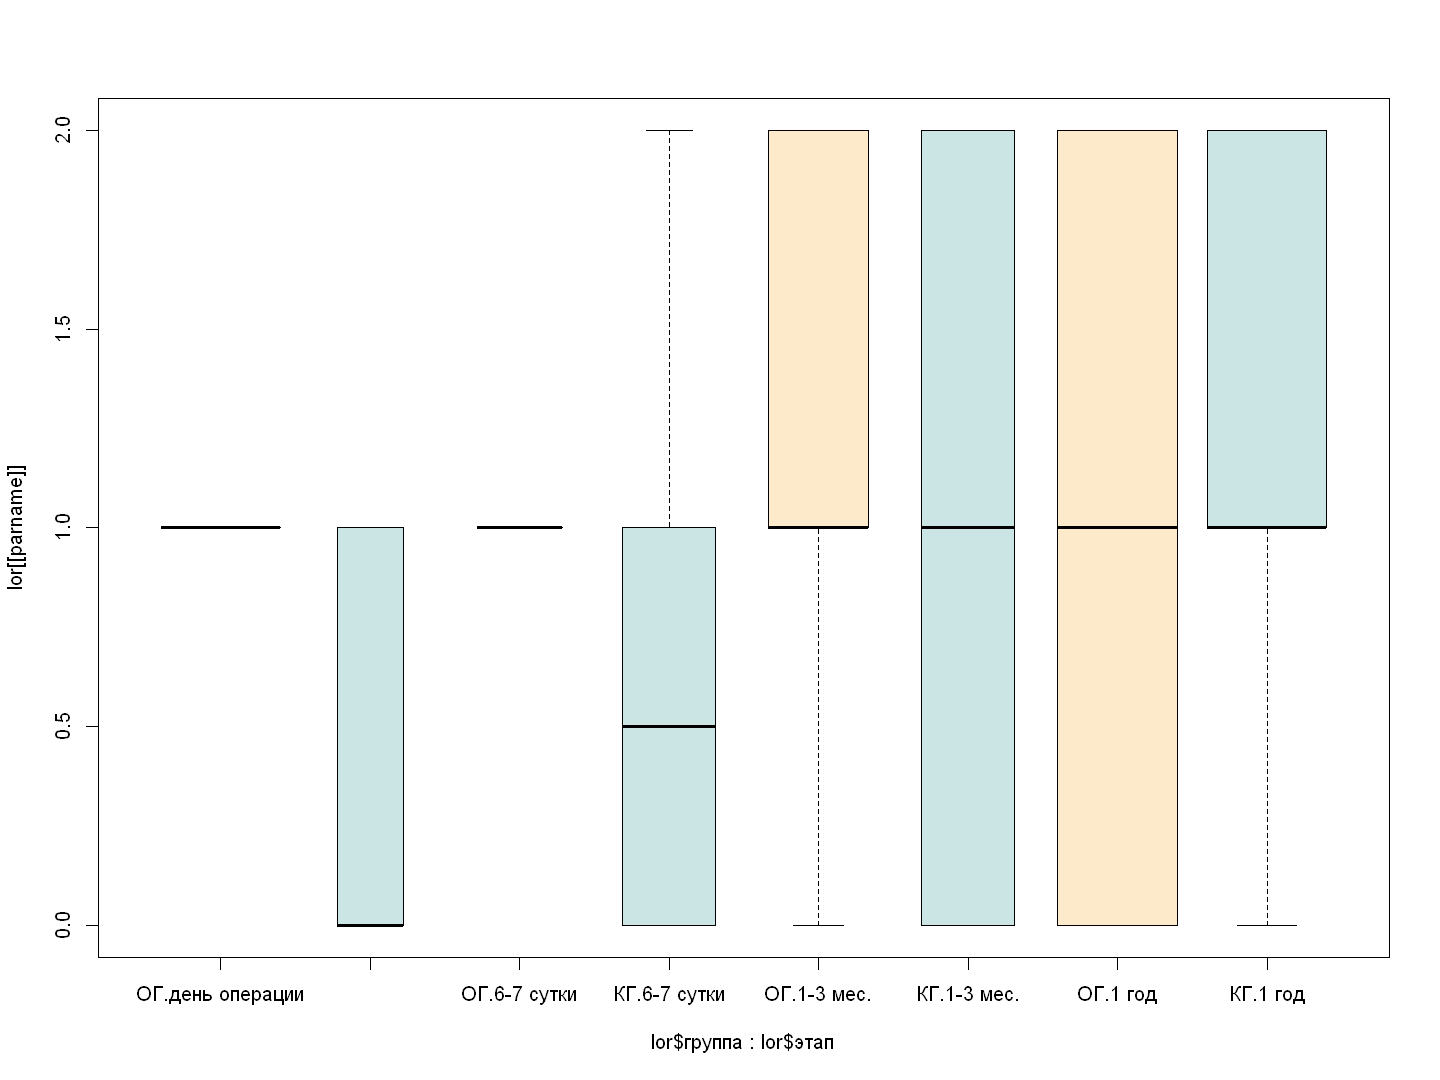

In [37]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 570, p-value = 0.0006295
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 3.4273, p-value = 0.0006095
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 432.5, p-value = 0.2938
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.0591, p-value = 0.2896
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 652, p-value = 0.07464
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.7897, p-value 

## плоскоклеточная метаплазия

### Общее

In [39]:
parname = "плоскоклеточная метаплазия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

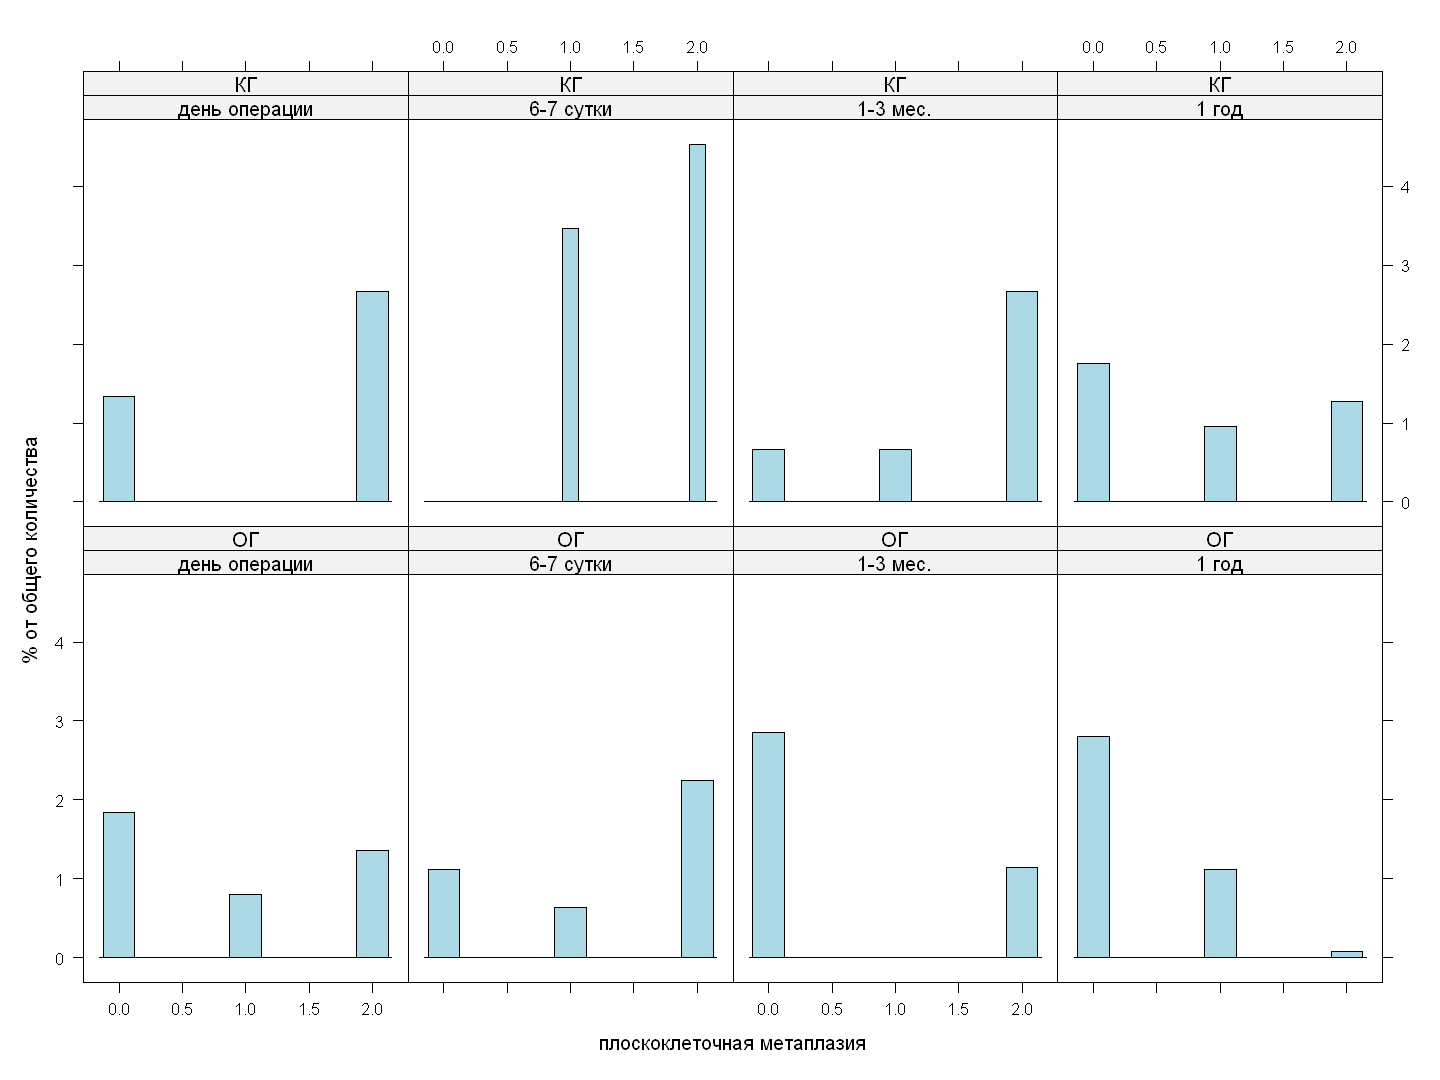

In [40]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      1.5000000 0.7768193   1  0   1   2   2    2     30
КГ: 1 год         0.8800000 0.8722479   2  0   0   1   2    2     50
КГ: 6-7 сутки     1.5666667 0.5040069   1  1   1   2   2    2     30
КГ: день операции 1.3333333 0.9759001   2  0   0   2   2    2     15
ОГ: 1-3 мес.      0.5714286 0.9166985   2  0   0   0   2    2     35
ОГ: 1 год         0.3200000 0.5126960   1  0   0   0   1    2     50
ОГ: 6-7 сутки     1.2800000 0.8906926   2  0   0   2   2    2     25
ОГ: день операции 0.8800000 0.8953394   2  0   0   1   2    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,1,2,2,0.8800000,0.8953394,50,0
КГ.день операции,0,0,2,2,2,1.3333333,0.9759001,15,0
ОГ.6-7 сутки,0,0,2,2,2,1.2800000,0.8906926,25,0
КГ.6-7 сутки,1,1,2,2,2,1.5666667,0.5040069,30,0
ОГ.1-3 мес.,0,0,0,2,2,0.5714286,0.9166985,35,0
КГ.1-3 мес.,0,1,2,2,2,1.5000000,0.7768193,30,0
ОГ.1 год,0,0,0,1,2,0.3200000,0.5126960,50,0
КГ.1 год,0,0,1,2,2,0.8800000,0.8722479,50,0


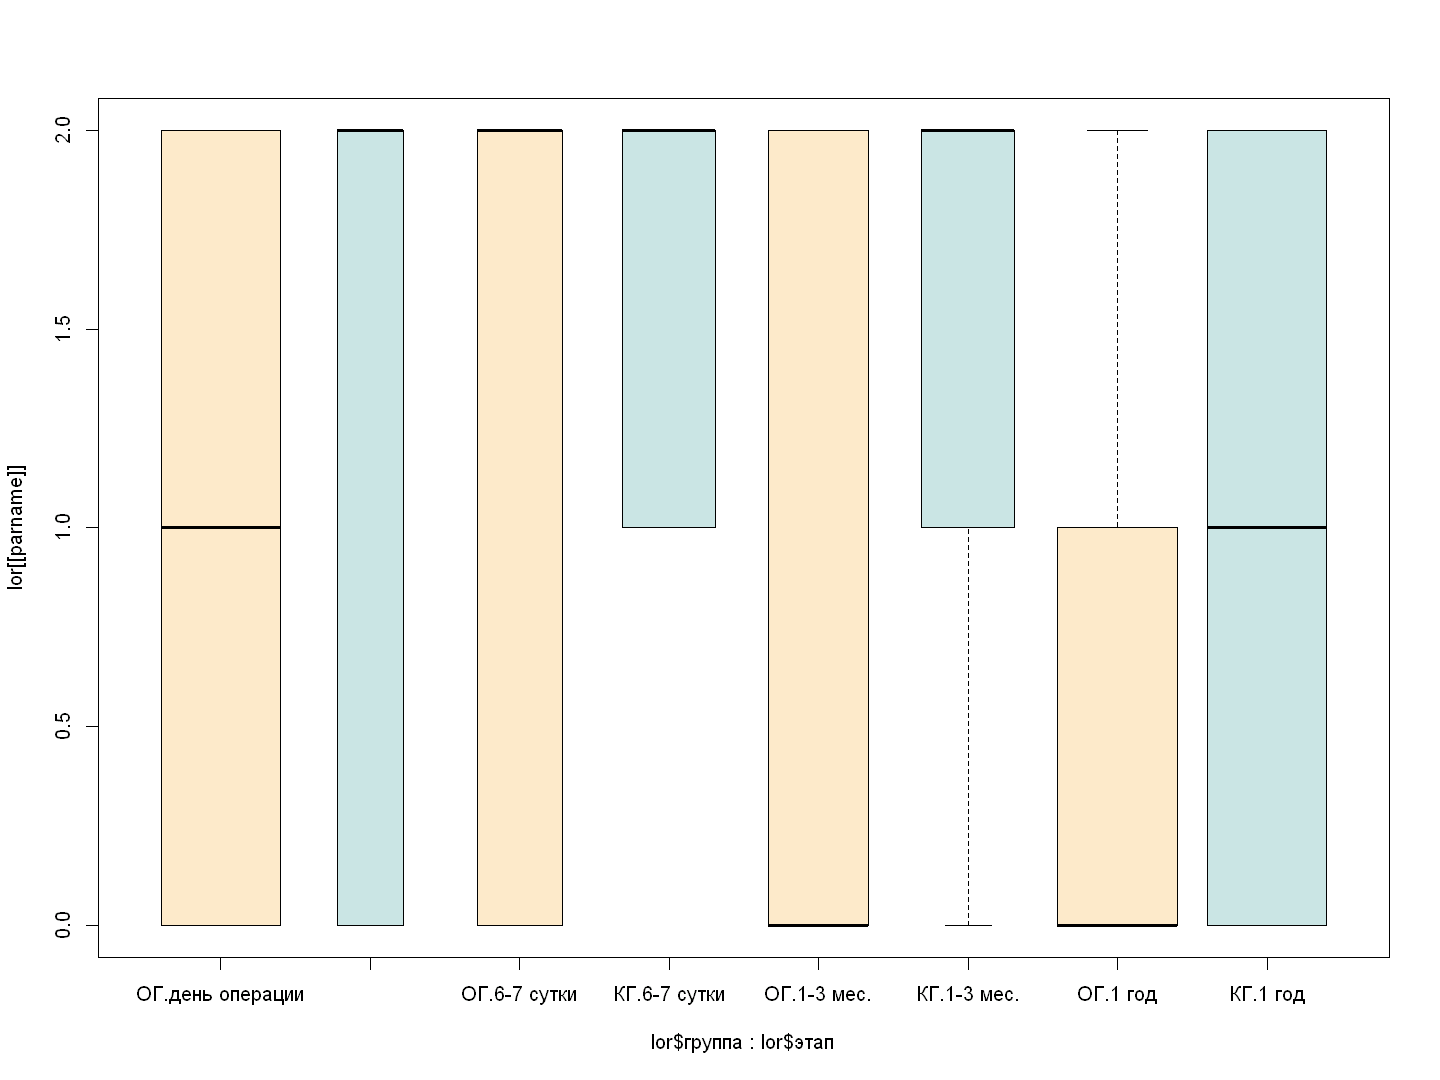

In [42]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [43]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 277.5, p-value = 0.1004
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.6515, p-value = 0.09864
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 327, p-value = 0.3662
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.91306, p-value = 0.3612
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 262.5, p-value = 0.0001195
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.8545, p-val

## эозинофилы

### Общее

In [44]:
parname = "эозинофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [45]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [46]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.      0.3333333 0.6608946   0  0   0   0   0    2     30
КГ: 1 год         0.7800000 1.2170557   1  0   0   0   1    3     50
КГ: 6-7 сутки     0.0000000 0.0000000   0  0   0   0   0    0     30
КГ: день операции 0.2000000 0.4140393   0  0   0   0   0    1     15
ОГ: 1-3 мес.      0.3714286 0.9727376   0  0   0   0   0    3     35
ОГ: 1 год         0.0000000 0.0000000   0  0   0   0   0    0     50
ОГ: 6-7 сутки     0.6800000 0.9000000   1  0   0   0   1    3     25
ОГ: день операции 0.5000000 1.0738069   0  0   0   0   0    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0,3,0.5000000,1.0738069,50,0
КГ.день операции,0,0,0,0,1,0.2000000,0.4140393,15,0
ОГ.6-7 сутки,0,0,0,1,3,0.6800000,0.9000000,25,0
КГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,30,0
ОГ.1-3 мес.,0,0,0,0,3,0.3714286,0.9727376,35,0
КГ.1-3 мес.,0,0,0,0,2,0.3333333,0.6608946,30,0
ОГ.1 год,0,0,0,0,0,0.0000000,0.0000000,50,0
КГ.1 год,0,0,0,1,3,0.7800000,1.2170557,50,0


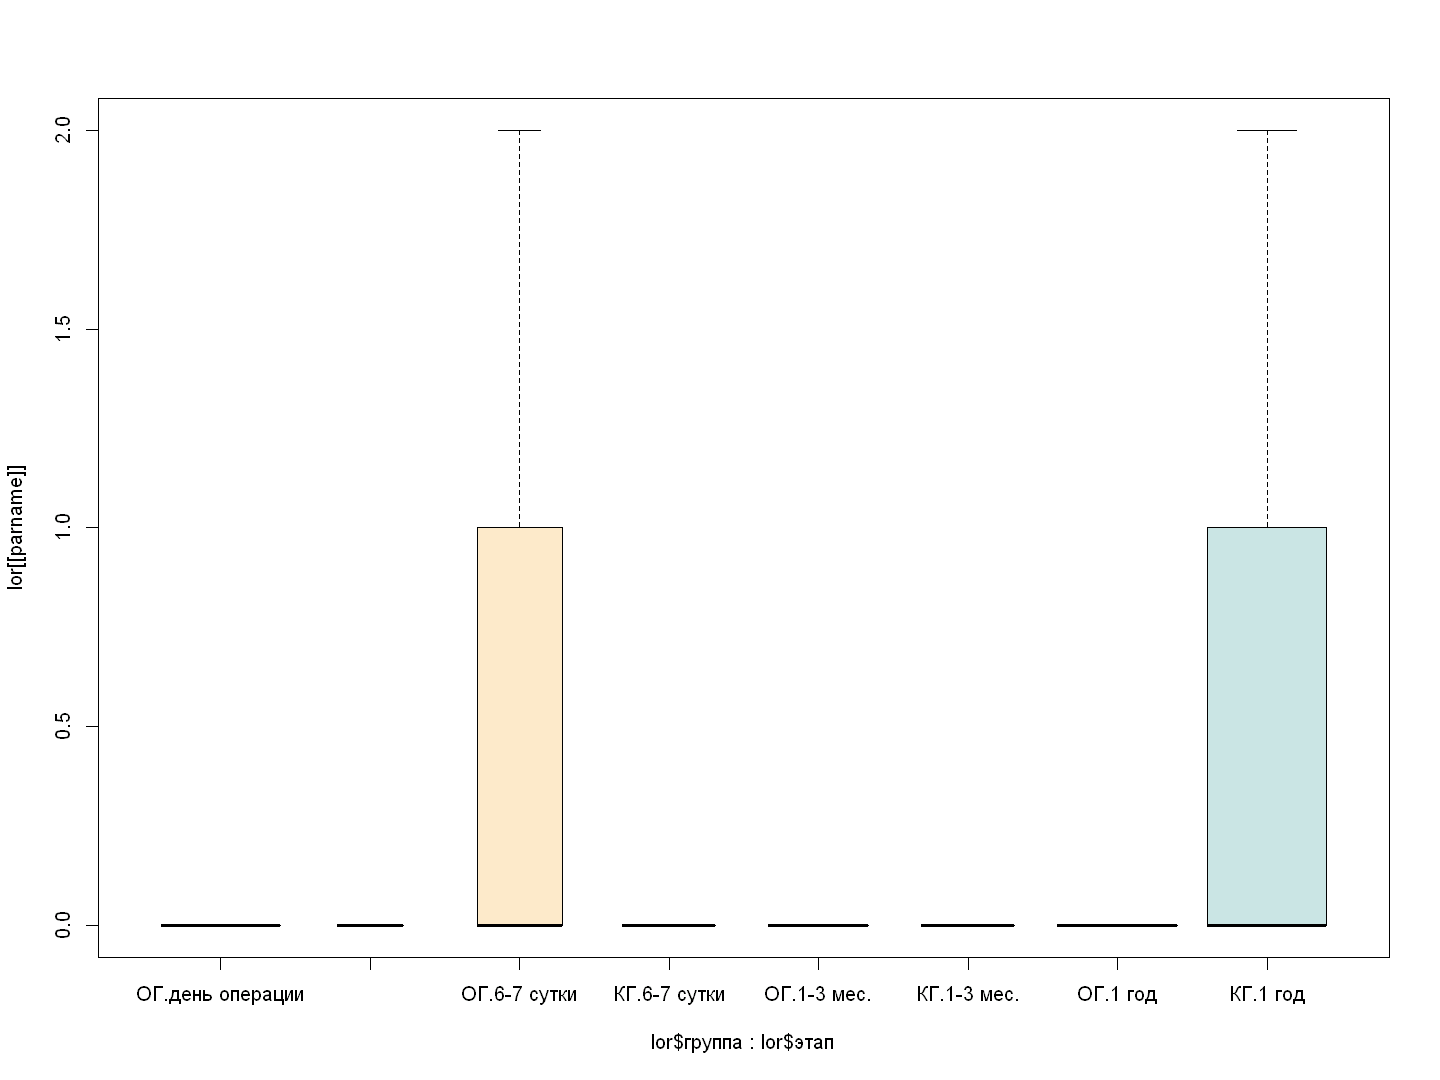

In [47]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [48]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 387, p-value = 0.7974
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.2679, p-value = 0.7888
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 555, p-value = 2.484e-05
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 4.228, p-value = 2.358e-05
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 490, p-value = 0.502
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -0.68114, p-value = 0

## нейтрофилы

### Общее

In [49]:
parname = "нейтрофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [50]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [51]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                        mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.      0.96666667 1.4015591 3.00  0   0   0 3.00    3     30
КГ: 1 год         0.12000000 0.3282607 0.00  0   0   0 0.00    1     50
КГ: 6-7 сутки     1.50000000 1.1371471 1.75  0   1   1 2.75    3     30
КГ: день операции 0.00000000 0.0000000 0.00  0   0   0 0.00    0     15
ОГ: 1-3 мес.      0.02857143 0.1690309 0.00  0   0   0 0.00    1     35
ОГ: 1 год         0.00000000 0.0000000 0.00  0   0   0 0.00    0     50
ОГ: 6-7 сутки     0.88000000 0.7257180 1.00  0   0   1 1.00    3     25
ОГ: день операции 0.10000000 0.3030458 0.00  0   0   0 0.00    1     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0.00,1,0.10000000,0.3030458,50,0
КГ.день операции,0,0,0,0.00,0,0.00000000,0.0000000,15,0
ОГ.6-7 сутки,0,0,1,1.00,3,0.88000000,0.7257180,25,0
КГ.6-7 сутки,0,1,1,2.75,3,1.50000000,1.1371471,30,0
ОГ.1-3 мес.,0,0,0,0.00,1,0.02857143,0.1690309,35,0
КГ.1-3 мес.,0,0,0,3.00,3,0.96666667,1.4015591,30,0
ОГ.1 год,0,0,0,0.00,0,0.00000000,0.0000000,50,0
КГ.1 год,0,0,0,0.00,1,0.12000000,0.3282607,50,0


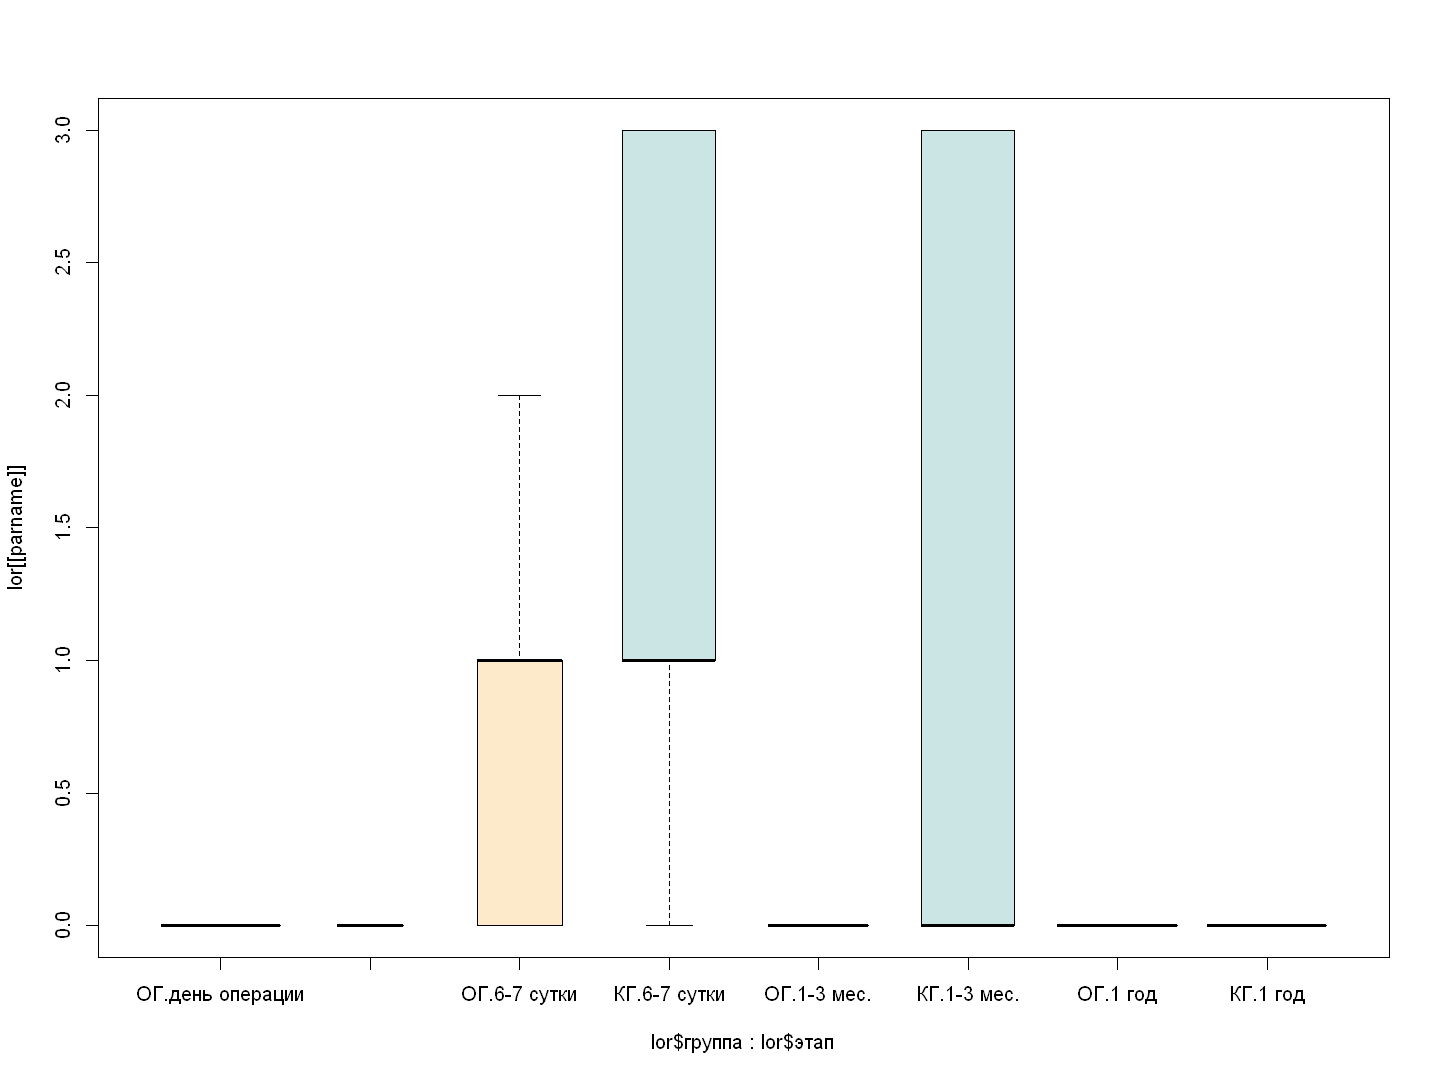

In [52]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [53]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 412.5, p-value = 0.212
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.2649, p-value = 0.2059
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 261, p-value = 0.04237
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -2.0388, p-value = 0.04147
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 360, p-value = 0.000887
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.3342, p-value = 